# XY, XXZ, and J1-J2 Spin Chains

**Model.** This notebook compares finite XY, XXZ, and frustrated J1-J2 spin chains using dense exact diagonalization.

**Typical uses.** Comparing spin-model conventions, studying anisotropy and frustration, selecting benchmark Hamiltonians, and checking finite-chain gap behavior.

**Parameters.** XY anisotropy `gamma`, XXZ anisotropy `Delta`, frustration ratio `J2/J1`, field, and `n_sites` define the demonstrated model families.

**Useful plots.** Shared-scale representative spectra and three parameter-dependent spectral-gap sweeps.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from quantum_lattice_models.models import j1_j2_heisenberg_chain, xxz_chain, xy_chain
from quantum_lattice_models.plotting import plot_lattice_spectrum
from quantum_lattice_models.spectra import ground_energy, spectral_gap

In [2]:
n_sites = 6
models = {
    "XY (gamma=0.5)": xy_chain(n_sites, coupling=1.0, anisotropy=0.5, field=0.7),
    "XXZ (Delta=1.0)": xxz_chain(n_sites, coupling=1.0, anisotropy=1.0),
    "J1-J2 (J2=0.5)": j1_j2_heisenberg_chain(n_sites, j1=1.0, j2=0.5),
}

print("model | shape | ground energy | spectral gap")
print("--- | --- | --- | ---")
for label, H in models.items():
    print(f"{label} | {H.shape} | {ground_energy(H): .6f} | {spectral_gap(H): .6f}")

model | shape | ground energy | spectral gap
--- | --- | --- | ---
XY (gamma=0.5) | (64, 64) | -5.027442 |  0.040929
XXZ (Delta=1.0) | (64, 64) | -9.974309 |  1.966327
J1-J2 (J2=0.5) | (64, 64) | -9.000000 |  2.116518


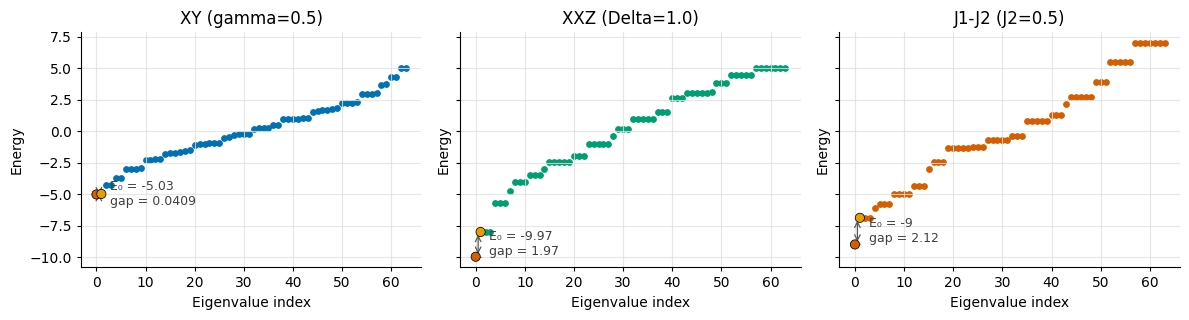

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.3), sharey=True)
colors = ["#0072B2", "#009E73", "#D55E00"]
for ax, (label, H), color in zip(axes, models.items(), colors, strict=True):
    plot_lattice_spectrum(H, ax=ax, s=15, color=color, highlight_gap=True)
    ax.set_title(label)
fig.tight_layout()

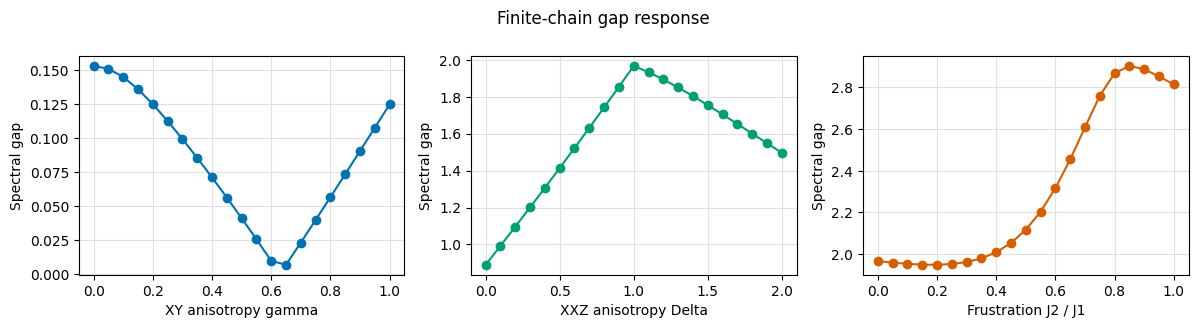

In [4]:
xy_values = np.linspace(0.0, 1.0, 21)
xxz_values = np.linspace(0.0, 2.0, 21)
j2_values = np.linspace(0.0, 1.0, 21)

xy_gaps = [
    spectral_gap(xy_chain(n_sites, coupling=1.0, anisotropy=float(value), field=0.7))
    for value in xy_values
]
xxz_gaps = [
    spectral_gap(xxz_chain(n_sites, coupling=1.0, anisotropy=float(value))) for value in xxz_values
]
j2_gaps = [
    spectral_gap(j1_j2_heisenberg_chain(n_sites, j1=1.0, j2=float(value))) for value in j2_values
]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.3))
axes[0].plot(xy_values, xy_gaps, marker="o", color="#0072B2")
axes[0].set_xlabel("XY anisotropy gamma")
axes[1].plot(xxz_values, xxz_gaps, marker="o", color="#009E73")
axes[1].set_xlabel("XXZ anisotropy Delta")
axes[2].plot(j2_values, j2_gaps, marker="o", color="#D55E00")
axes[2].set_xlabel("Frustration J2 / J1")
for ax in axes:
    ax.set_ylabel("Spectral gap")
    ax.grid(color="0.88", linewidth=0.8)
fig.suptitle("Finite-chain gap response")
fig.tight_layout()